# Predicción de Rango de Precios de Móviles — (refactorizado)

Este notebook orquesta el pipeline usando las clases del paquete `mobile_price_classification`.
Toda la lógica reutilizable (carga de datos, features, gráficos, entrenamiento, predicción)
vive en el paquete; aquí solo se ejecuta el flujo end-to-end.

**Estructura del paquete usado:**
```
mobile_price_classification/
├── config.py              # rutas y constantes
├── dataset.py              # DataLoader
├── features.py             # FeatureEngineer
├── plots.py                 # EDAPlotter
└── modeling/
    ├── train.py             # ModelTrainer
    └── predict.py            # Predictor
```


## 0. Setup: permitir importar el paquete desde /notebooks

In [27]:
import sys
from pathlib import Path

# Permite importar mobile_price_classification/ estando dentro de notebooks/
PROJ_ROOT = Path.cwd().parent
if str(PROJ_ROOT) not in sys.path:
    sys.path.append(str(PROJ_ROOT))

import pandas as pd

from mobile_price_classification.config import CLASS_LABELS
from mobile_price_classification.dataset import DataLoader
from mobile_price_classification.features import FeatureEngineer
from mobile_price_classification.plots import EDAPlotter
from mobile_price_classification.modeling.train import ModelTrainer
from mobile_price_classification.modeling.predict import Predictor


## 1. Carga de datos

In [28]:
loader = DataLoader()
train_df = loader.load_train()
test_df = loader.load_test()

print("Shape train:", train_df.shape)
print("Shape test:", test_df.shape)
train_df.head()


19:13:16 | INFO | mobile_price_classification | Cargando datos de entrenamiento desde E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\data\raw\train.csv
19:13:16 | INFO | mobile_price_classification | Cargando datos de prueba desde E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\data\raw\test.csv


Shape train: (2000, 21)
Shape test: (1000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [29]:
train_df.describe().T


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


## 2. EDA

19:13:16 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
e:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\mobile_price_classification\plots.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET_COLUMN, data=df, palette="viridis", ax=ax)
19:13:16 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:16 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\target_distribution.png


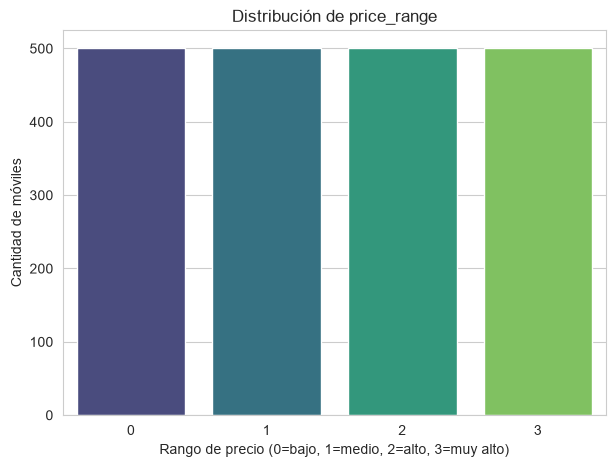

In [30]:
plotter = EDAPlotter()
plotter.plot_target_distribution(train_df)


19:13:19 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\numeric_distributions.png


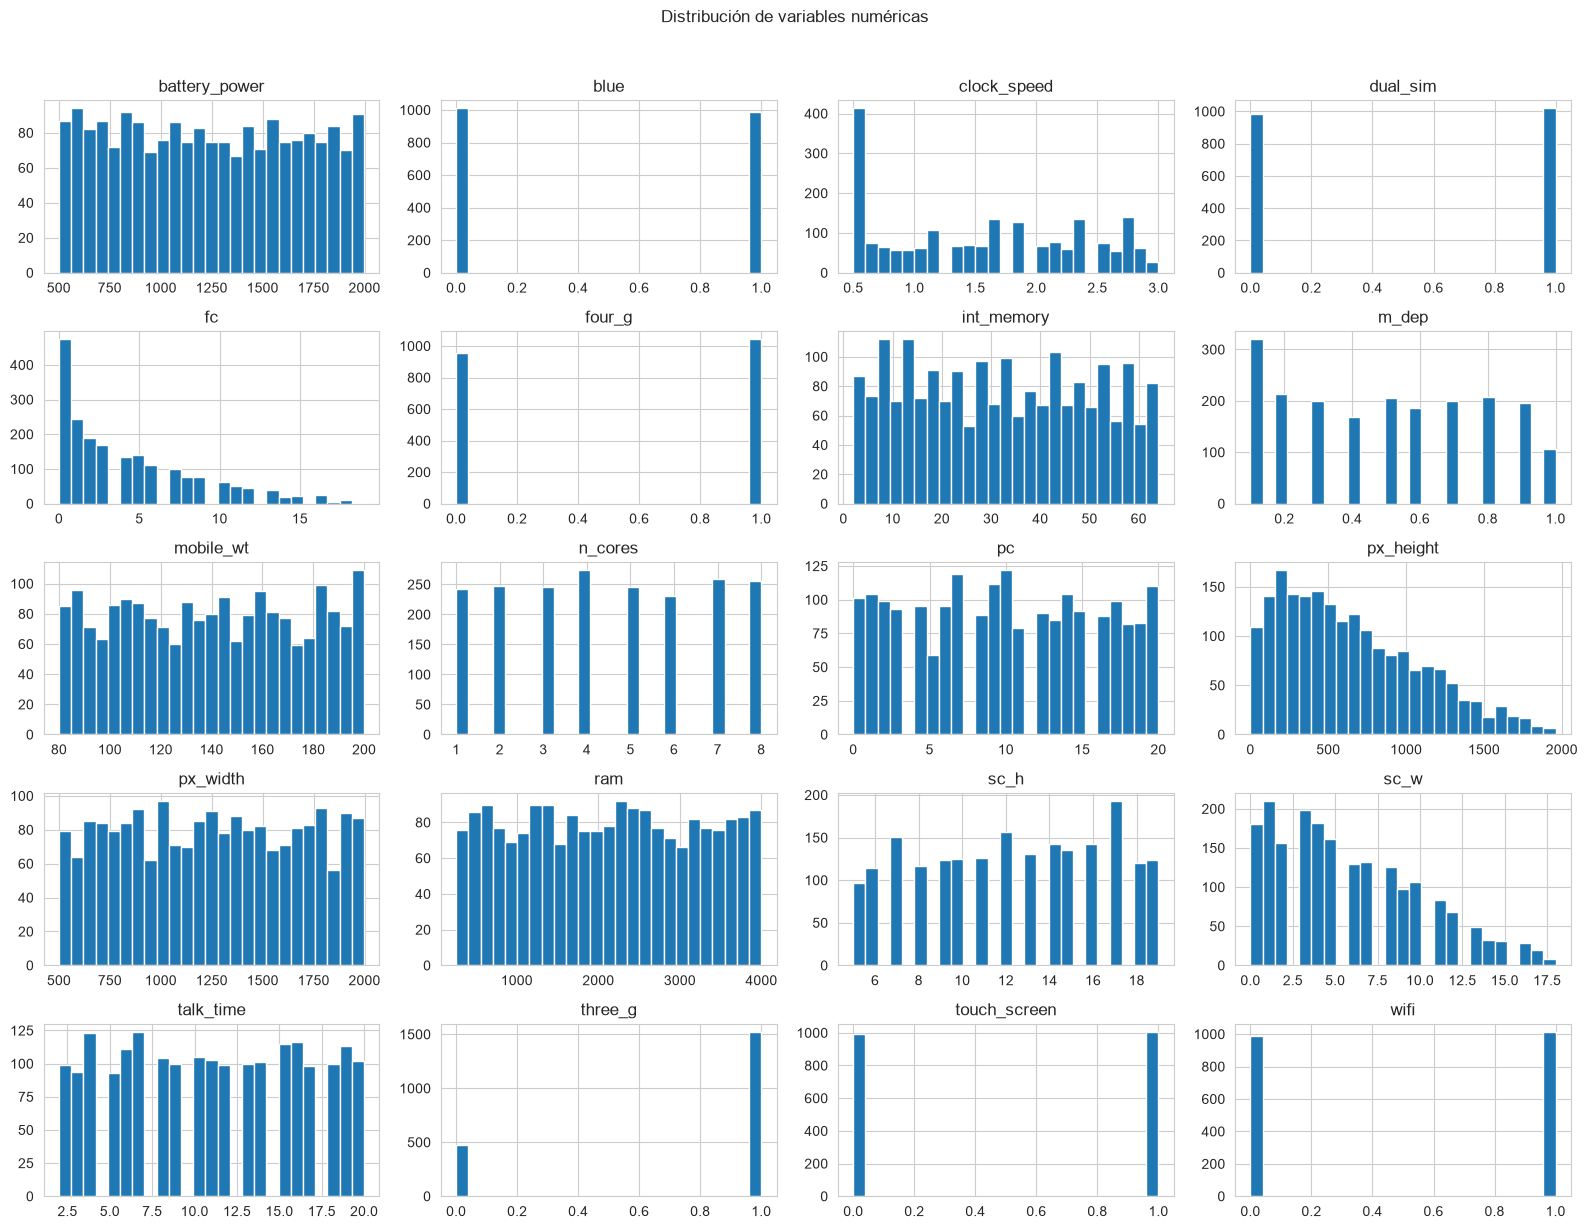

In [31]:
plotter.plot_numeric_distributions(train_df, exclude=["price_range"])


19:13:21 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:21 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:21 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:21 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:21 | INFO | matplotlib.category | Using categorical units to plot a list o

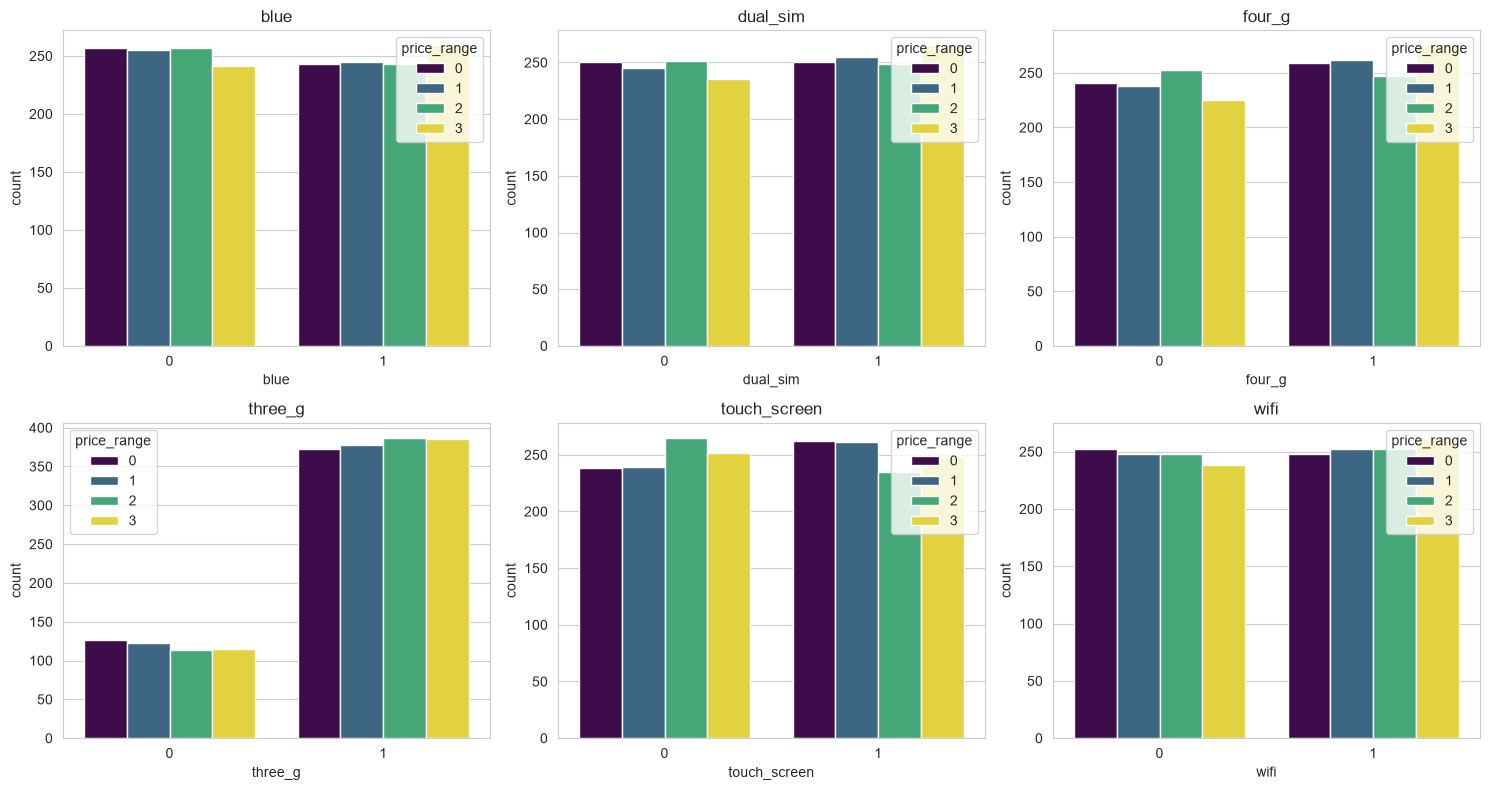

In [32]:
binary_cols = ["blue", "dual_sim", "four_g", "three_g", "touch_screen", "wifi"]
plotter.plot_binary_features(train_df, binary_cols)


19:13:23 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\correlation_matrix.png


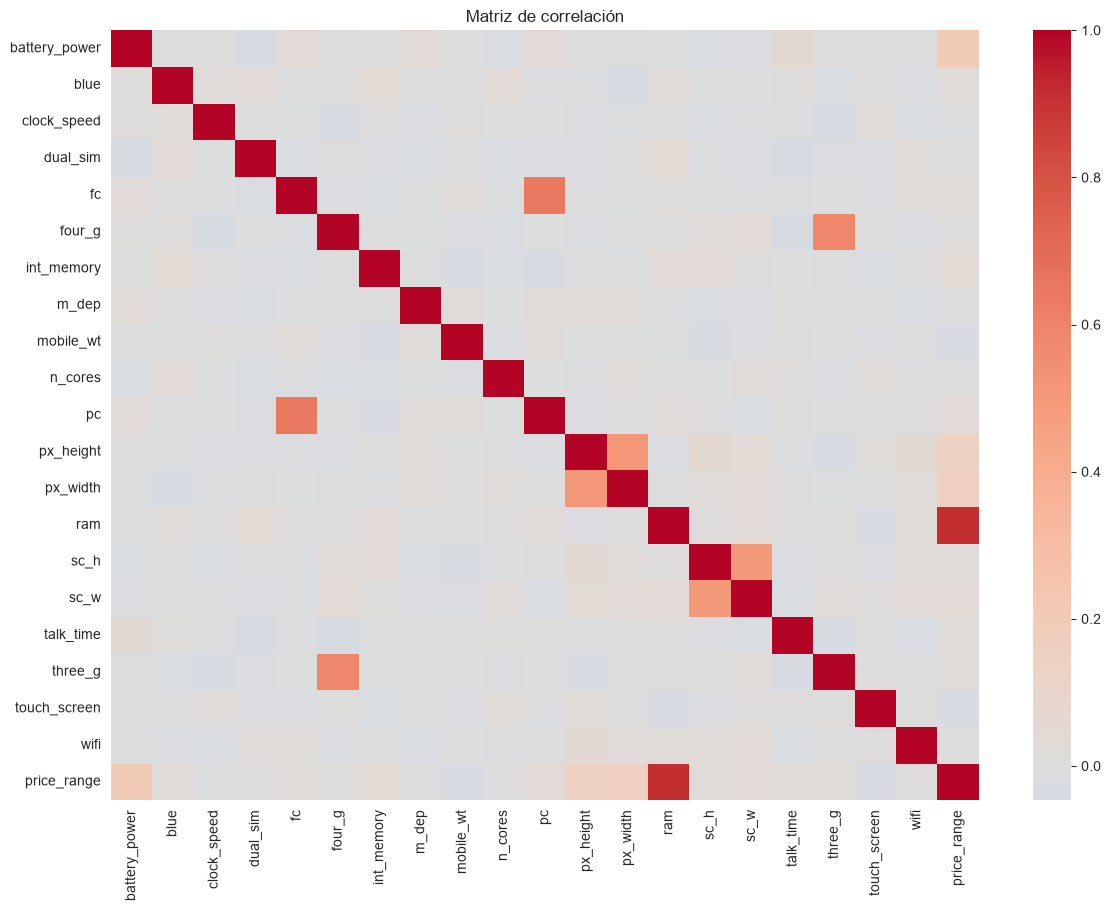

19:13:23 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\correlation_with_target.png


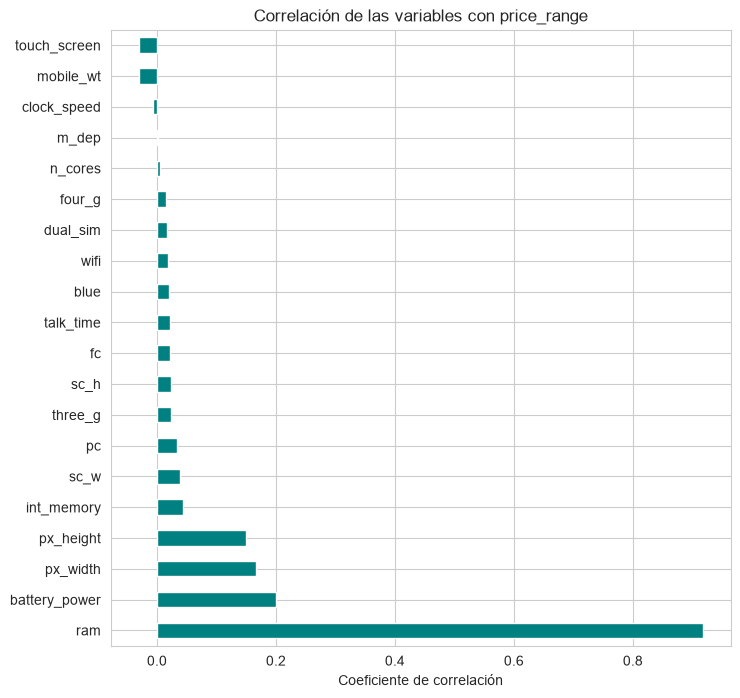

ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64

In [33]:
corr_target = plotter.plot_correlation_matrix(train_df)
plotter.plot_correlation_with_target(corr_target)
corr_target


19:13:23 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
e:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\mobile_price_classification\plots.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET_COLUMN, y=column, data=df, palette="viridis", ax=ax)
19:13:23 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:24 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\boxplot_ram_vs_target.png


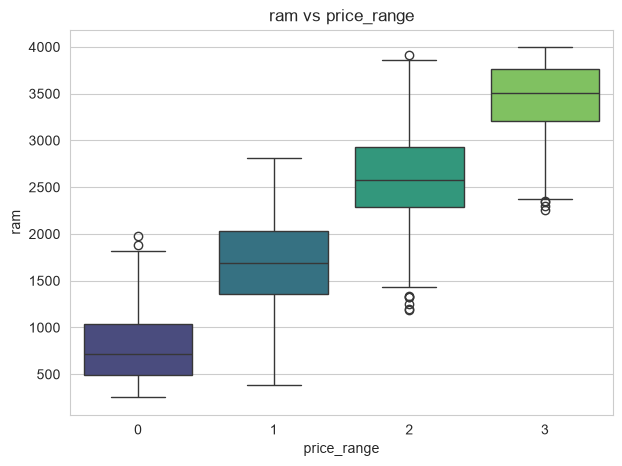

19:13:24 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
e:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\mobile_price_classification\plots.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=TARGET_COLUMN, y=column, data=df, palette="viridis", ax=ax)
19:13:24 | INFO | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
19:13:24 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\boxplot_battery_power_vs_target.png


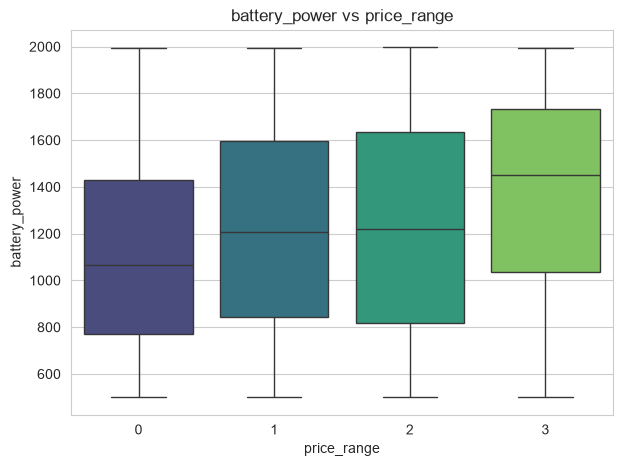

In [34]:
plotter.plot_boxplot_vs_target(train_df, "ram")
plotter.plot_boxplot_vs_target(train_df, "battery_power")


19:13:24 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\scatter_px_width_vs_px_height.png


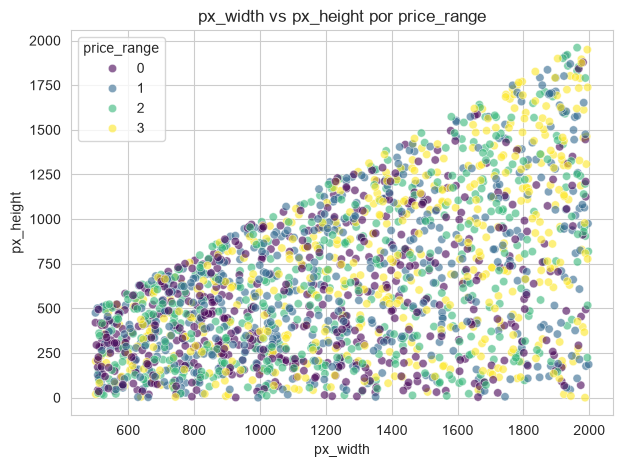

In [35]:
plotter.plot_scatter(train_df, x="px_width", y="px_height")


19:13:25 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\outliers.png


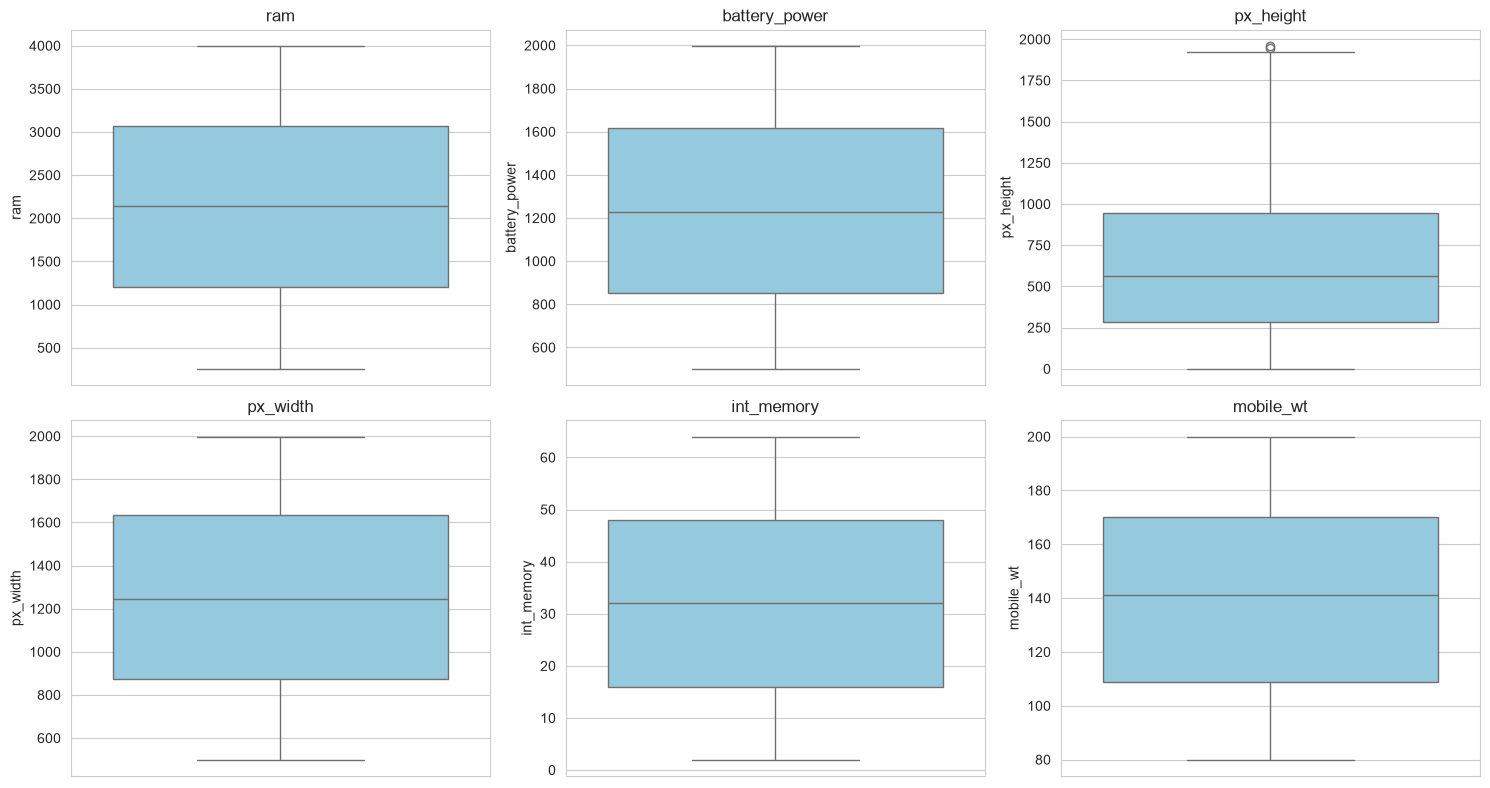

In [36]:
key_cols = ["ram", "battery_power", "px_height", "px_width", "int_memory", "mobile_wt"]
plotter.plot_outliers(train_df, key_cols)


## 3. Preprocesamiento: split + escalado

In [37]:
X, y = loader.get_features_target(train_df)

fe = FeatureEngineer()
X_train, X_val, y_train, y_val = fe.split(X, y)

X_train_scaled = fe.fit_transform(X_train)
X_val_scaled = fe.transform(X_val)

# Escalado sobre el dataset completo (para CV y para el modelo final)
fe_full = FeatureEngineer()
X_full_scaled = fe_full.fit_transform(X)

fe_full.save_scaler()  # models/scaler.pkl

print("Train:", X_train_scaled.shape, "Val:", X_val_scaled.shape)


19:13:26 | INFO | mobile_price_classification | Scaler guardado en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\models\scaler.pkl


Train: (1600, 20) Val: (400, 20)


## 4. Entrenamiento y comparación de modelos

In [38]:
trainer = ModelTrainer()
results_df = trainer.compare_models(
    X_train_scaled, y_train, X_val_scaled, y_val, X_full_scaled, y
)
results_df


19:13:26 | INFO | mobile_price_classification | Entrenando Logistic Regression...
19:13:26 | INFO | mobile_price_classification | Entrenando KNN...
19:13:26 | INFO | mobile_price_classification | Entrenando Naive Bayes...
19:13:26 | INFO | mobile_price_classification | Entrenando Decision Tree...
19:13:26 | INFO | mobile_price_classification | Entrenando Random Forest...
19:13:32 | INFO | mobile_price_classification | Entrenando Gradient Boosting...
19:13:40 | INFO | mobile_price_classification | Entrenando SVM...
19:13:41 | INFO | mobile_price_classification | Comparación de modelos guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\models\models_comparison.json


,Modelo,Accuracy (validación),CV Accuracy (media),CV Accuracy (std)
0,Logistic Regression,0.9650,0.9630,0.004848
1,Gradient Boosting,0.9125,0.9025,0.009747
2,SVM,0.8950,0.8850,0.020248
3,Random Forest,0.8825,0.8840,0.010794
4,Decision Tree,0.8300,0.8225,0.010488
5,Naive Bayes,0.8100,0.8090,0.016016
6,KNN,0.5625,0.5440,0.025377


e:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\mobile_price_classification\plots.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x=metric, y="Modelo", palette="viridis", ax=ax)
19:13:41 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\model_comparison.png


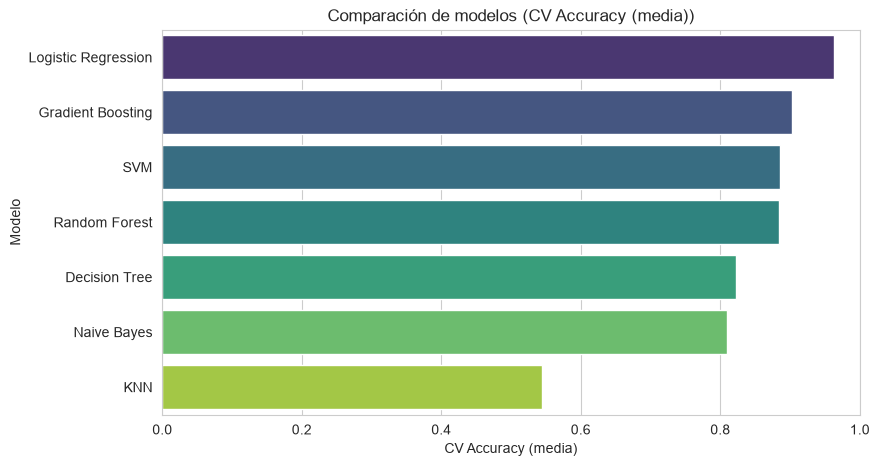

In [39]:
plotter.plot_model_comparison(results_df)


### 4.1 Ajuste fino del mejor modelo

Ajusta `param_grid` según el modelo que haya quedado primero en `results_df`.


In [40]:
best_model_name = results_df.iloc[0]["Modelo"]
print("Mejor modelo según CV:", best_model_name)

# Ejemplo de grid para SVM; cambia las llaves si el mejor modelo es otro
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}

best_model = trainer.tune_best_model(
    X_full_scaled, y, model_name="SVM", param_grid=param_grid
)


19:13:41 | INFO | mobile_price_classification | Ejecutando GridSearchCV para SVM...


Mejor modelo según CV: Logistic Regression


19:13:58 | INFO | mobile_price_classification | Mejores parámetros: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
19:13:58 | INFO | mobile_price_classification | Mejor accuracy (CV): 0.9740


## 5. Evaluación del modelo final

In [41]:
from sklearn.metrics import accuracy_score, classification_report

best_model.fit(X_train_scaled, y_train)
y_val_pred = best_model.predict(X_val_scaled)

print("Accuracy en validación:", accuracy_score(y_val, y_val_pred))
print()
print(classification_report(y_val, y_val_pred))


Accuracy en validación: 0.9725

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       0.96      0.96      0.96       100
           2       0.95      0.95      0.95       100
           3       0.99      0.98      0.98       100

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



19:13:59 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\confusion_matrix.png


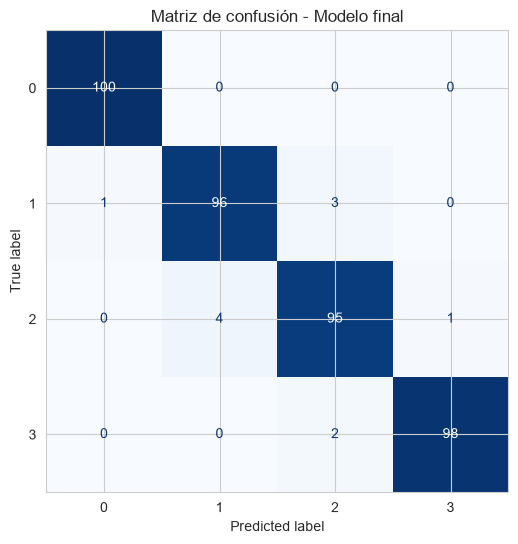

In [42]:
plotter.plot_confusion_matrix(y_val, y_val_pred, labels=list(CLASS_LABELS.keys()))


19:14:00 | INFO | mobile_price_classification | Figura guardada en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\figures\feature_importance.png


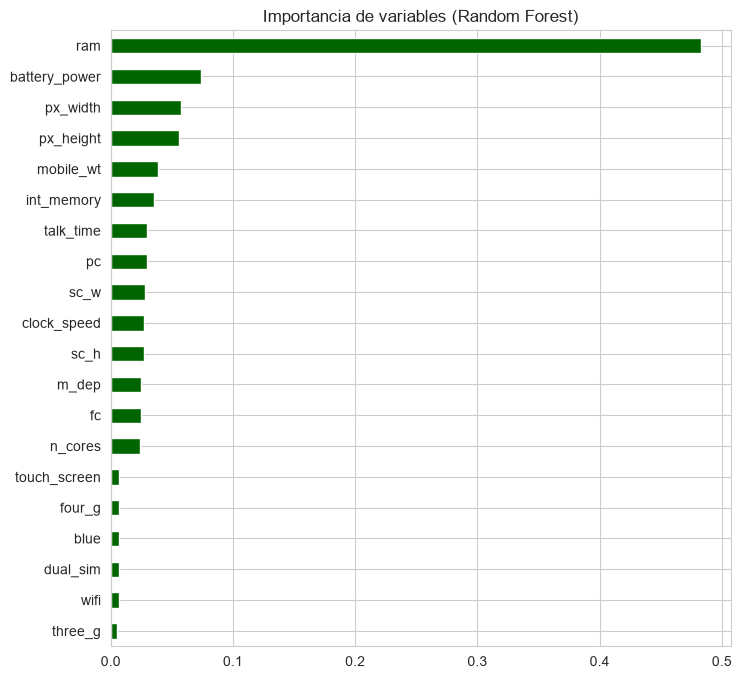

ram              0.483102
battery_power    0.074234
px_width         0.057801
px_height        0.055615
mobile_wt        0.038501
int_memory       0.035762
talk_time        0.029916
pc               0.029594
sc_w             0.027995
clock_speed      0.027190
sc_h             0.027058
m_dep            0.025176
fc               0.024971
n_cores          0.023648
touch_screen     0.006934
four_g           0.006910
blue             0.006904
dual_sim         0.006794
wifi             0.006703
three_g          0.005192
dtype: float64

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)  # sin escalar, RF no lo necesita

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plotter.plot_feature_importance(importances)
importances


## 6. Guardar el modelo final (models/best_model.pkl)

In [44]:
# Reentrenar con TODO el dataset disponible antes de guardar
best_model.fit(X_full_scaled, y)
trainer.save_model(best_model)  # -> models/best_model.pkl


19:14:01 | INFO | mobile_price_classification | Modelo guardado en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\models\best_model.pkl


## 7. Predicciones sobre test.csv usando el Predictor

In [45]:
predictor = Predictor()
predictor.load()  # carga models/best_model.pkl y models/scaler.pkl

submission = predictor.predict_test(test_df)
predictor.save_submission(submission)  # -> reports/predicciones_test.csv

submission.head(10)


19:14:01 | INFO | mobile_price_classification | Cargando modelo desde E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\models\best_model.pkl
19:14:01 | INFO | mobile_price_classification | Cargando scaler desde E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\models\scaler.pkl
19:14:01 | INFO | mobile_price_classification | Predicciones guardadas en E:\Mobile_Price_Class_MLOPS\Mobile_Price_Class_MLOps\reports\predicciones_test.csv


,id,price_range
0,1,3
1,2,3
2,3,2
3,4,3
4,5,1
5,6,3
6,7,3
7,8,1
8,9,3
9,10,0


## 8. Conclusiones

- `ram` es la variable con mayor poder predictivo sobre `price_range`.
- El pipeline completo (EDA, features, entrenamiento, predicción) ahora vive en
  el paquete `mobile_price_classification/`, reutilizable desde este notebook,
  desde scripts, o desde tests unitarios.
- Artefactos generados:
    - `models/scaler.pkl`
    - `models/best_model.pkl`
    - `models/models_comparison.json`
    - `models/best_model_params.json`
    - `reports/figures/*.png`
    - `reports/predicciones_test.csv`
